# Comparación de Condiciones

El dataset escogido es sobre precios de casas en EEUU. Se quiere ver si hay una diferencia significativa en precios por pies cuadrados de las casas grandes contra las casas pequeñas.

In [7]:
import os
from pathlib import Path
from functools import cache

import kagglehub
import pandas as pd


def get_cache_dir() -> Path:
    """
    Creates and returns the cache directory for kagglehub.
    """
    cache_dir = Path.cwd() / "data" / "raw"
    cache_dir.mkdir(parents=True, exist_ok=True)

    os.environ["KAGGLEHUB_CACHE"] = str(cache_dir)

    return cache_dir


@cache
def get_data() -> pd.DataFrame:
    """
    Downloads the dataset from Kaggle and loads it into a DataFrame.
    """

    print("Cache directory:", get_cache_dir())

    data_path = kagglehub.dataset_download(
        "debayank2024/house-price-prediction"
    )

    file_path = Path(data_path) / "modified_data.csv"

    df = pd.read_csv(file_path)

    print("Path to file:", file_path)

    return df

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from plotnine import *

df = get_data()

Cache directory: c:\Users\yoser\source\repos\Experimentos_TempName\AC4-Comparacion-Condiciones\data\raw
Path to file: c:\Users\yoser\source\repos\Experimentos_TempName\AC4-Comparacion-Condiciones\data\raw\datasets\debayank2024\house-price-prediction\versions\1\modified_data.csv


### División del dataset por tamaño de vivienda

Con el fin de poder realizar la prueba T con los grupos "casas pequeñas" y "casas grandes", se decide dividir el dataset utilizando la mediana de la variable sqft_living como punto de división.

In [8]:
# Mediana de sqft_living
mediana_sqft = df['sqft_living'].median()

# División en dos dataframes: casas pequeñas y casas grandes
casas_pequenas = df[df['sqft_living'] < mediana_sqft].copy()
casas_grandes = df[df['sqft_living'] >= mediana_sqft].copy()

# Transformación logarítmica de price_per_sqft
casas_pequenas = casas_pequenas.copy()
casas_grandes = casas_grandes.copy()

casas_pequenas["price_per_sqft"] = casas_pequenas[
    "price_per_sqft"
].replace([np.inf, -np.inf], np.nan)

casas_grandes["price_per_sqft"] = casas_grandes[
    "price_per_sqft"
].replace([np.inf, -np.inf], np.nan)

casas_pequenas.loc[
    casas_pequenas["price_per_sqft"] <= 0,
    "price_per_sqft"
] = np.nan

casas_grandes.loc[
    casas_grandes["price_per_sqft"] <= 0,
    "price_per_sqft"
] = np.nan

casas_pequenas["log_price_per_sqft"] = np.log(
    casas_pequenas["price_per_sqft"]
)

casas_grandes["log_price_per_sqft"] = np.log(
    casas_grandes["price_per_sqft"]
)

### Prueba de normalidad

Antes de aplicar una prueba de normalidad, primero observamos su distribución.


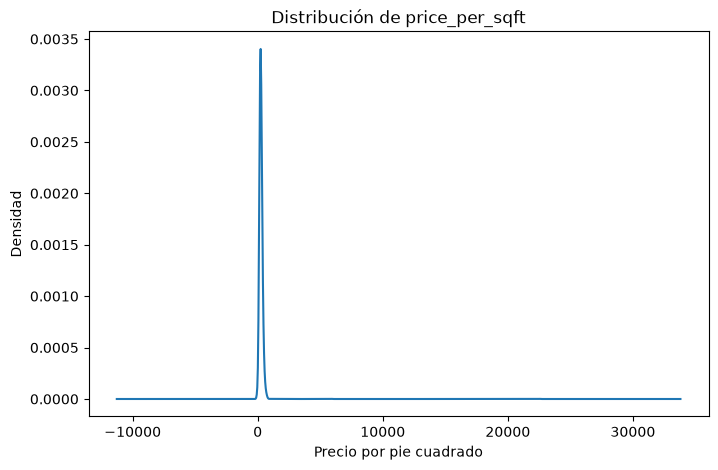

In [31]:
import matplotlib.pyplot as plt

df['price_per_sqft'].dropna().plot(
    kind='kde',
    figsize=(8, 5)
)

plt.title("Distribución de price_per_sqft")
plt.xlabel("Precio por pie cuadrado")
plt.ylabel("Densidad")
plt.show()

Se le aplica la transformación logarítima porque los datos no se ven simétricos, aparte de que tienen un rango muy amplio. 

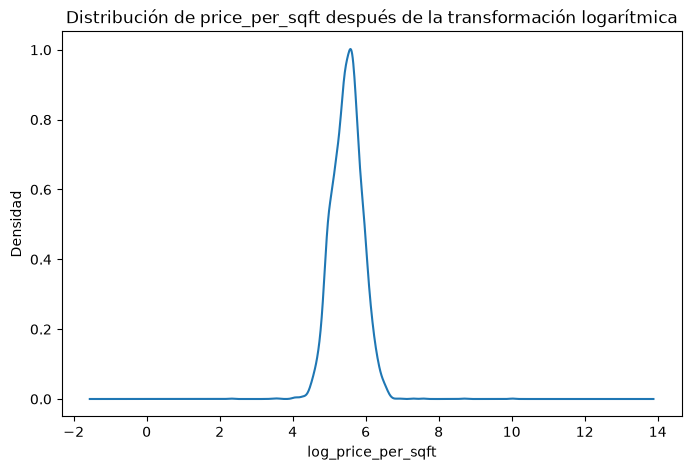

In [33]:
datos_log = pd.concat([
    casas_pequenas["log_price_per_sqft"],
    casas_grandes["log_price_per_sqft"]
]).replace(
    [np.inf, -np.inf], np.nan
).dropna()

datos_log.plot(
    kind="kde",
    figsize=(8, 5)
)

plt.title("Distribución de price_per_sqft después de la transformación logarítmica")
plt.xlabel("log_price_per_sqft")
plt.ylabel("Densidad")
plt.show()



Ya con la distribución logarítmica aplicada, se ve un poco más simétrica. Entonces, se utiliza la prueba de Lilliefors para verificar la normalidad de `log_price_per_sqft` en ambos grupos.

**H0:** Los datos siguen una distribución normal.
**H1:** Los datos no siguen una distribución normal.

In [43]:
variable = "log_price_per_sqft"

datos_pequenas = casas_pequenas[variable].replace(
    [np.inf, -np.inf], np.nan
).dropna()

datos_grandes = casas_grandes[variable].replace(
    [np.inf, -np.inf], np.nan
).dropna()

from statsmodels.stats.diagnostic import lilliefors

stat_pequenas, p_pequenas = lilliefors(
    datos_pequenas,
    dist="norm"
)

stat_grandes, p_grandes = lilliefors(
    datos_grandes,
    dist="norm"
)

print(
    f"Casas pequeñas - D: {stat_pequenas:.4f}, "
    f"p-valor: {p_pequenas:.6f}"
)

print(
    f"Casas grandes - D: {stat_grandes:.4f}, "
    f"p-valor: {p_grandes:.6f}"
)

Casas pequeñas - D: 0.0315, p-valor: 0.001000
Casas grandes - D: 0.0318, p-valor: 0.001000


Por el valor del p, se rechaza H0, y ninguno de los grupos sigue una distribución normal, según Lilliefors. Sin embargo, se observa el Q-Q.

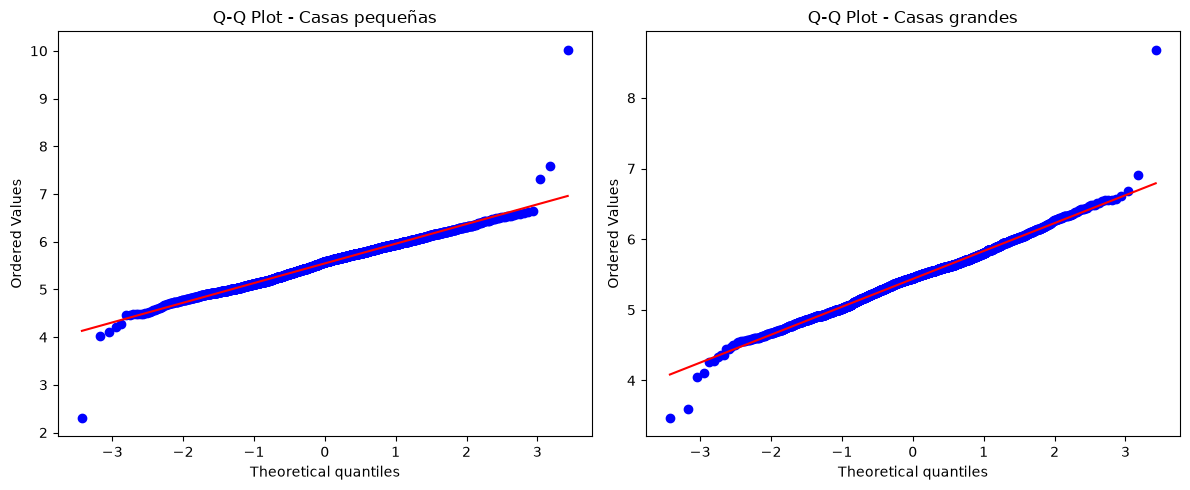

In [48]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(
    datos_pequenas,
    dist="norm",
    plot=axes[0]
)
axes[0].set_title("Q-Q Plot - Casas pequeñas")

stats.probplot(
    datos_grandes,
    dist="norm",
    plot=axes[1]
)
axes[1].set_title("Q-Q Plot - Casas grandes")

plt.tight_layout()
plt.show()

Los gráficos Q-Q muestran que los datos sí parecen normales, sólo que tienen varios valores atípicos/extremos en ambos grupos. Según Terán-García, "dado que se basa en la media y la desviación estándar de la muestra para estimar los parámetros de la distribución normal, la prueba de Lilliefors es bastante sensible a la presencia de valores atípicos" (2024). Lo cual explica que nos de que los datos no son normales aunque los gráficos apunten a que sí.

Debido a que el enfoque del análisis es la prueba T, y considerando que visualmente la desviación de la normalidad se concentra principalmente en los extremos, se continúa verificando la prueba de varianzas.

### Prueba de igualdad de varianzas (Brown-Forsythe)

Para verificar la hipótesis de igualdad de varianzas entre los grupos de casas pequeñas y casas 
grandes, se utilizó la prueba de Brown-Forsythe, modificación de la prueba de Levene que centra los grupos usando la mediana en vez de la media. La razón de utilizar esta prueba se debe a que en el EDA realizado anteriormente con el dataset se descubrieron multiples valores atípicos en la variable price_per_sqft. La hipótesis plantea que la varianza de ambos grupos son iguales.

**H0:** Las medias de `log_price_per_sqft` son iguales en ambos grupos.  
**H1:** Las medias de `log_price_per_sqft` son diferentes entre los grupos.

In [52]:
from scipy import stats

alpha = 0.05

stat_bf, p_bf = stats.levene(
    datos_pequenas,
    datos_grandes,
    center="median"
)

print(f"Estadístico Brown-Forsythe: {stat_bf:.4f}")
print(f"p-valor: {p_bf:.6f}")

Estadístico Brown-Forsythe: 10.1681
p-valor: 0.001439


### Prueba T de Welch

El resultado de Brown-Forsythe sobre `log_price_per_sqft` determina si se utiliza una prueba t de Student o una prueba t de Welch. Y tenemos que:

H0: La media de log_price_per_sqft es igual para las casas pequeñas y las casas grandes.
H1: La media de log_price_per_sqft es diferente entre las casas pequeñas y las casas grandes.

In [56]:
alpha = 0.05

# Brown-Forsythe determina si se asumen varianzas iguales
equal_var = p_bf >= alpha

# Prueba t
stat_t, p_t = stats.ttest_ind(
    datos_pequenas,
    datos_grandes,
    equal_var=equal_var
)

print(f"Prueba t utilizada: {'Student' if equal_var else 'Welch'}")
print(f"Estadístico t: {stat_t:.4f}")

if p_t < 0.001:
    print("p-valor: < 0.001")
else:
    print(f"p-valor: {p_t:.4f}")

print(f"Media casas pequeñas: {datos_pequenas.mean():.4f}")
print(f"Media casas grandes: {datos_grandes.mean():.4f}")

if p_t < alpha:
    print("Se rechaza H0: sí existe una diferencia significativa entre las medias.")
else:
    print("No se rechaza H0: no hay evidencia suficiente de una diferencia entre las medias.")

Prueba t utilizada: Welch
Estadístico t: 8.8179
p-valor: < 0.001
Media casas pequeñas: 5.5445
Media casas grandes: 5.4376
Se rechaza H0: sí existe una diferencia significativa entre las medias.


En conclusión, la prueba T de Welch muestra que el tamaño de la vivienda está asociado con diferencias en el precio por pie cuadrado. Aunque los datos no cumplieron la normalidad según Lilliefors, los gráficos Q-Q mostraron un comportamiento aproximadamente normal en la mayor parte de la distribución. Además, Brown-Forsythe indicó que las varianzas eran diferentes, por lo que se utilizó la prueba T de Welch, la cual confirmó una diferencia significativa entre ambos grupos.

### Referencias
Terán-García, E., & Pérez-Fernández, R. (2024). Una alternativa sólida a la prueba de normalidad de Lilliefors. Revista de simulación y computación estadística , 94 (7), 1494-1512. https://doi.org/10.1080/00949655.2023.2291138 